In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from svm import SVM
from svm import get_class
from sklearn.preprocessing import StandardScaler

<h3> Считывание данных </h3>

In [2]:
df = pd.read_csv("iris.csv")

data = df[["Sepal.L", "Sepal.W","Kind "]].to_numpy()
data[:50, 2] = 1
data[50:, 2] = -1

In [3]:
data

array([[5.1, 3.5, 1],
       [4.9, 3.0, 1],
       [4.7, 3.2, 1],
       [4.6, 3.1, 1],
       [5.0, 3.6, 1],
       [5.4, 3.9, 1],
       [4.6, 3.4, 1],
       [5.0, 3.4, 1],
       [4.4, 2.9, 1],
       [4.9, 3.1, 1],
       [5.4, 3.7, 1],
       [4.8, 3.4, 1],
       [4.8, 3.0, 1],
       [4.3, 3.0, 1],
       [5.8, 4.0, 1],
       [5.7, 4.4, 1],
       [5.4, 3.9, 1],
       [5.1, 3.5, 1],
       [5.7, 3.8, 1],
       [5.1, 3.8, 1],
       [5.4, 3.4, 1],
       [5.1, 3.7, 1],
       [4.6, 3.6, 1],
       [5.1, 3.3, 1],
       [4.8, 3.4, 1],
       [5.0, 3.0, 1],
       [5.0, 3.4, 1],
       [5.2, 3.5, 1],
       [5.2, 3.4, 1],
       [4.7, 3.2, 1],
       [4.8, 3.1, 1],
       [5.4, 3.4, 1],
       [5.2, 4.1, 1],
       [5.5, 4.2, 1],
       [4.9, 3.1, 1],
       [5.0, 3.2, 1],
       [5.5, 3.5, 1],
       [4.9, 3.1, 1],
       [4.4, 3.0, 1],
       [5.1, 3.4, 1],
       [5.0, 3.5, 1],
       [4.5, 2.3, 1],
       [4.4, 3.2, 1],
       [5.0, 3.5, 1],
       [5.1, 3.8, 1],
       [4.

<h3> Построение диаграммы рассеяния признаков </h3>

Text(0, 0.5, 'Sepal.W')

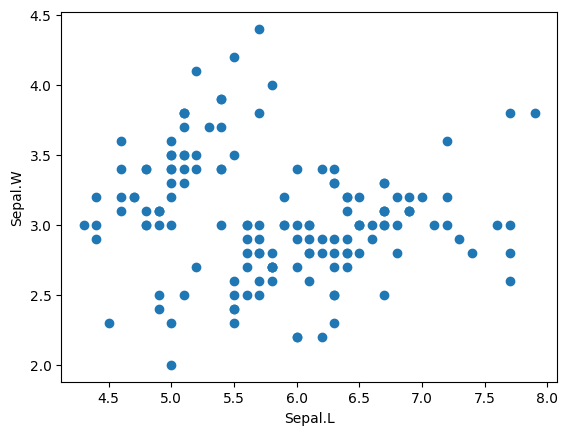

In [4]:
plt.scatter(data[:, 0], data[:, 1])
plt.xlabel("Sepal.L")
plt.ylabel("Sepal.W")

<h3> Разбиение датасета на обучающую/тестовую выборки, построение модели </h3>

<h5> Первая итериция </h5>

In [5]:
x_train, x_test, y_train, y_test = train_test_split(data[:, :-1], data[:, -1], random_state=1337, train_size=100)
svm = SVM(kernel="linear", learning_rate=0.3, epochs=500)
svm.fit(x_train, y_train)

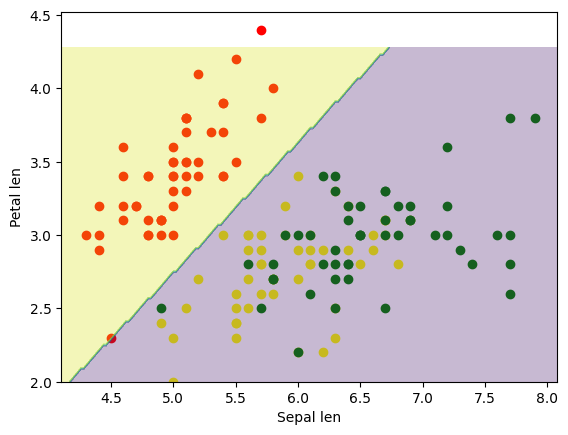

In [6]:
x1_min, x1_max = x_test[:, 0].min()-0.2, x_test[:, 0].max()+0.2
x2_min, x2_max = x_test[:, 1].min()-0.2, x_test[:, 1].max()+0.2
x1_points, x2_points = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

svm_anses = svm.predict(np.array([x1_points.ravel(), x2_points.ravel()]).T)
svm_anses = predicted_values = get_class(svm_anses)
svm_anses = svm_anses.reshape(x1_points.shape)


plt.scatter(data[0:50, 0], data[0:50, 1], color='red')
plt.scatter(data[51:100, 0], data[51:100, 1], color='yellow')
plt.scatter(data[100:150, 0], data[100:150, 1], color='green')
plt.xlabel("Sepal len")
plt.ylabel("Petal len")
plt.contourf(x1_points, x2_points, svm_anses, alpha=0.3)
plt.show()

In [7]:
y_predicted = get_class(svm.predict(x_test))
accuracy = (y_predicted == y_test).sum() / len (y_test) * 100

print(f"Точность классификации на тестовой выборке: {accuracy}%")

Точность классификации на тестовой выборке: 100.0%


In [8]:
y_predicted = get_class(svm.predict(x_train))
accuracy = (y_predicted == y_train).sum() / len (y_train) * 100

print(f"Точность классификации на обучающей выборке: {accuracy}%")

Точность классификации на обучающей выборке: 100.0%


<h5> Вторая итериция </h5>

In [9]:
x_train, x_test, y_train, y_test = train_test_split(data[:, :-1], data[:, -1], random_state=228, train_size=100)
svm = SVM(kernel="linear", learning_rate=0.3, epochs=500)
svm.fit(x_train, y_train)

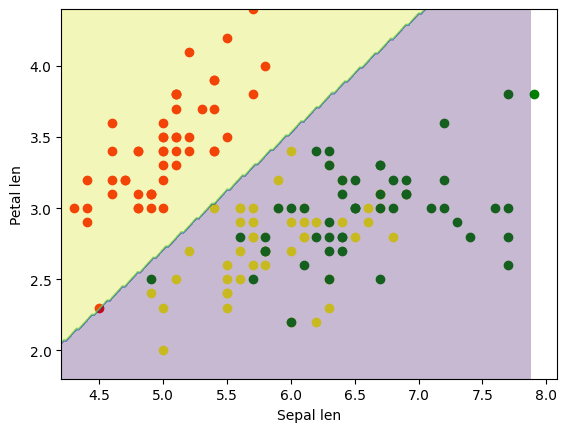

In [10]:
x1_min, x1_max = x_test[:, 0].min()-0.2, x_test[:, 0].max()+0.2
x2_min, x2_max = x_test[:, 1].min()-0.2, x_test[:, 1].max()+0.2
x1_points, x2_points = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

svm_anses = svm.predict(np.array([x1_points.ravel(), x2_points.ravel()]).T)
svm_anses = predicted_values = get_class(svm_anses)
svm_anses = svm_anses.reshape(x1_points.shape)


plt.scatter(data[0:50, 0], data[0:50, 1], color='red')
plt.scatter(data[51:100, 0], data[51:100, 1], color='yellow')
plt.scatter(data[100:150, 0], data[100:150, 1], color='green')
plt.xlabel("Sepal len")
plt.ylabel("Petal len")
plt.contourf(x1_points, x2_points, svm_anses, alpha=0.3)
plt.show()

In [11]:
y_predicted = get_class(svm.predict(x_test))
accuracy = (y_predicted == y_test).sum() / len (y_test) * 100

print(f"Точность классификации на тестовой выборке: {accuracy}%")

Точность классификации на тестовой выборке: 100.0%


In [12]:
y_predicted = get_class(svm.predict(x_train))
accuracy = (y_predicted == y_train).sum() / len (y_train) * 100

print(f"Точность классификации на обучающей выборке: {accuracy}%")

Точность классификации на обучающей выборке: 100.0%


<h5> Третья итериция </h5>

In [13]:
x_train, x_test, y_train, y_test = train_test_split(data[:, :-1], data[:, -1], random_state=42, train_size=100)
svm = SVM(kernel="linear", learning_rate=0.3, epochs=500)
svm.fit(x_train, y_train)

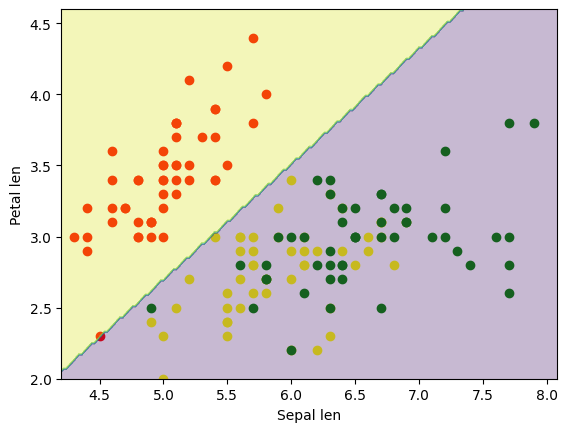

In [14]:
x1_min, x1_max = x_test[:, 0].min()-0.2, x_test[:, 0].max()+0.2
x2_min, x2_max = x_test[:, 1].min()-0.2, x_test[:, 1].max()+0.2
x1_points, x2_points = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

svm_anses = svm.predict(np.array([x1_points.ravel(), x2_points.ravel()]).T)
svm_anses = predicted_values = get_class(svm_anses)
svm_anses = svm_anses.reshape(x1_points.shape)


plt.scatter(data[0:50, 0], data[0:50, 1], color='red')
plt.scatter(data[51:100, 0], data[51:100, 1], color='yellow')
plt.scatter(data[100:150, 0], data[100:150, 1], color='green')
plt.xlabel("Sepal len")
plt.ylabel("Petal len")
plt.contourf(x1_points, x2_points, svm_anses, alpha=0.3)
plt.show()

In [15]:
y_predicted = get_class(svm.predict(x_test))
accuracy = (y_predicted == y_test).sum() / len (y_test) * 100

print(f"Точность классификации на тестовой выборке: {accuracy}%")

Точность классификации на тестовой выборке: 100.0%


In [16]:
y_predicted = get_class(svm.predict(x_train))
accuracy = (y_predicted == y_train).sum() / len (y_train) * 100

print(f"Точность классификации на обучающей выборке: {accuracy}%")

Точность классификации на обучающей выборке: 100.0%


<h3> Классификация с помощью SVM с квадратичным ядром </h3>

In [17]:
x_train, x_test, y_train, y_test = train_test_split(data[:, :-1], data[:, -1], random_state=42, train_size=100)
svm = SVM(kernel="quadratic", learning_rate=0.3, epochs=500)
svm.fit(x_train, y_train)

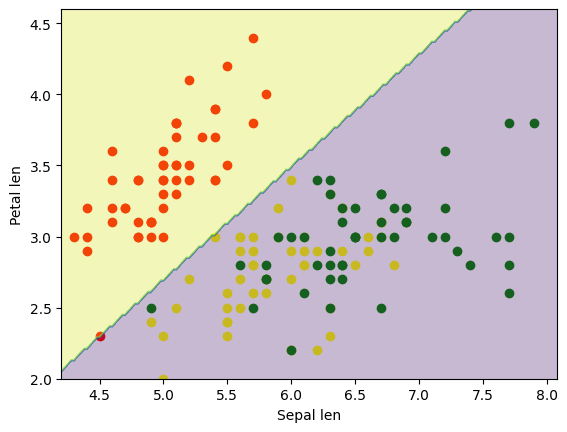

In [18]:
x1_min, x1_max = x_test[:, 0].min()-0.2, x_test[:, 0].max()+0.2
x2_min, x2_max = x_test[:, 1].min()-0.2, x_test[:, 1].max()+0.2
x1_points, x2_points = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

svm_anses = svm.predict(np.array([x1_points.ravel(), x2_points.ravel()]).T)
svm_anses = predicted_values = get_class(svm_anses)
svm_anses = svm_anses.reshape(x1_points.shape)


plt.scatter(data[0:50, 0], data[0:50, 1], color='red')
plt.scatter(data[51:100, 0], data[51:100, 1], color='yellow')
plt.scatter(data[100:150, 0], data[100:150, 1], color='green')
plt.xlabel("Sepal len")
plt.ylabel("Petal len")
plt.contourf(x1_points, x2_points, svm_anses, alpha=0.3)
plt.show()

In [19]:
y_predicted = get_class(svm.predict(x_test))
accuracy = (y_predicted == y_test).sum() / len (y_test) * 100

print(f"Точность классификации на тестовой выборке: {accuracy}%")

Точность классификации на тестовой выборке: 100.0%


In [20]:
y_predicted = get_class(svm.predict(x_train))
accuracy = (y_predicted == y_train).sum() / len (y_train) * 100

print(f"Точность классификации на обучающей выборке: {accuracy}%")

Точность классификации на обучающей выборке: 100.0%


<h3> Определение дополнительного сорта </h3>

In [21]:
df = pd.read_csv("Dop.csv")
data = df[["Sepal.L", "Sepal.W"]].to_numpy()

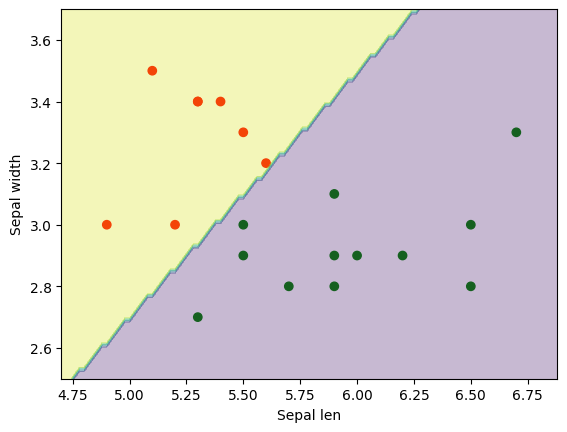

In [22]:
x1_min, x1_max = data[:, 0].min()-0.2, data[:, 0].max()+0.2
x2_min, x2_max = data[:, 1].min()-0.2, data[:, 1].max()+0.2
x1_points, x2_points = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

svm_anses = svm.predict(np.array([x1_points.ravel(), x2_points.ravel()]).T)
svm_anses = get_class(svm_anses)
svm_anses = svm_anses.reshape(x1_points.shape)
predicted_values = get_class(svm.predict(data))

classes = {1: "red", -1: "green"}
plt.scatter(data[:, 0], data[:, 1], color=[classes[y_pred] for y_pred in predicted_values])
plt.xlabel("Sepal len")
plt.ylabel("Sepal width")
plt.contourf(x1_points, x2_points, svm_anses, alpha=0.3)
plt.show()

<h3> Линейно неразделимый случай </h3>

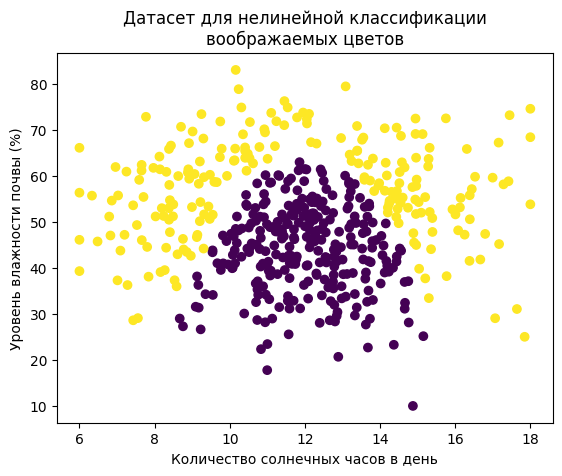

In [23]:
def separating_f(x:int):
    return - 3 * (x - 12) ** 2 + 65

sep_coef = 1 # служит для разделения классов по второму признаку (чтобы было пространство между ними)
X = list()

for i in range(500):
    point = [np.random.normal(loc=12, scale=2.5), np.random.normal(loc=50, scale=12)]
    X.append(point)

X = np.array([[point[0], point[1] + (sep_coef if point[1] > separating_f(point[0]) else -sep_coef)] for point in X])
X = np.clip(X, [6, 10], [18, 85])
y = np.array([1 if point[1] > separating_f(point[0]) else -1 for point in X])

# Визуализация датасета
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel('Количество солнечных часов в день')
plt.ylabel('Уровень влажности почвы (%)')
plt.title('Датасет для нелинейной классификации\nвоображаемых цветов')
plt.show()

In [24]:
scaler = StandardScaler()
x_transformed = scaler.fit_transform(X)

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_transformed[:, :], y[:], random_state=1337, train_size=400)

In [26]:
svm = SVM(kernel="quadratic", learning_rate=0.1, epochs=1000)
svm.fit(x_train, y_train)

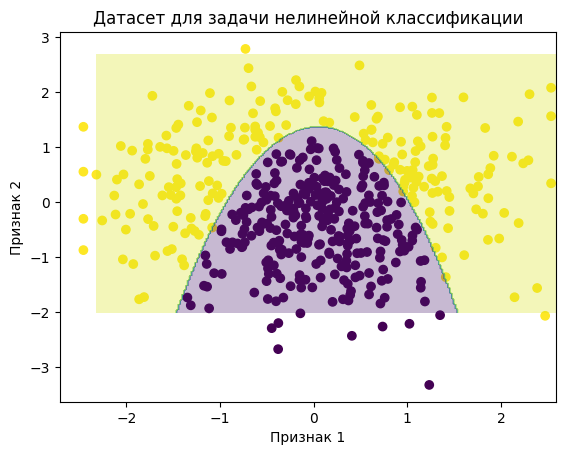

In [27]:
x1_min, x1_max = x_test[:, 0].min()-0.2, x_test[:, 0].max()+0.2
x2_min, x2_max = x_test[:, 1].min()-0.2, x_test[:, 1].max()+0.2
x1_points, x2_points = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

svm_anses = svm.predict(np.array([x1_points.ravel(), x2_points.ravel()]).T)
svm_anses = get_class(svm_anses)
svm_anses = svm_anses.reshape(x1_points.shape)

plt.scatter(x_transformed[:,0], x_transformed[:,1], c=y)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Датасет для задачи нелинейной классификации')
plt.contourf(x1_points, x2_points, svm_anses, alpha=0.3)
plt.show()

In [28]:
y_predicted = get_class(svm.predict(x_test))
accuracy = (y_predicted == y_test).sum() / len (y_test) * 100

print(f"Точность классификации на тестовой выборке: {accuracy}%")

Точность классификации на тестовой выборке: 100.0%


In [29]:
y_predicted = get_class(svm.predict(x_train))
accuracy = (y_predicted == y_train).sum() / len (y_train) * 100

print(f"Точность классификации на обучающей выборке: {accuracy}%")

Точность классификации на обучающей выборке: 100.0%


<h3> Гауссовское ядро </h3>

In [46]:
class GaussSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000, gamma=1.0):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.gamma = gamma
        self.w = None
        self.b = None

    def gaussian_kernel(self, x, y):
        return np.exp(-(np.linalg.norm(x - y) ** 2) / (2 * (self.gamma ** 2)))

    def transform_features(self, X):
        return np.c_[X, X[:, 0] * X[:, 1], X[:, 0] ** 2, X[:, 1] ** 2]

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)
        X_transformed = self.transform_features(X)
        self.w = np.zeros(n_features + 3)
        self.b = 0
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X_transformed):
                kernel = self.gaussian_kernel(x_i, x_i)
                condition = y_[idx] * (np.dot(self.w, kernel) - self.b) >= 1
                if np.all(condition):
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w - y_[idx] * kernel)
                    self.b -= self.learning_rate * y_[idx]

    def predict(self, X):
        X_transformed = self.transform_features(X)
        approx = np.dot(X_transformed, self.w) - self.b
        return np.sign(approx).flatten()

In [47]:
svm = GaussSVM()
svm.fit(x_train, y_train)

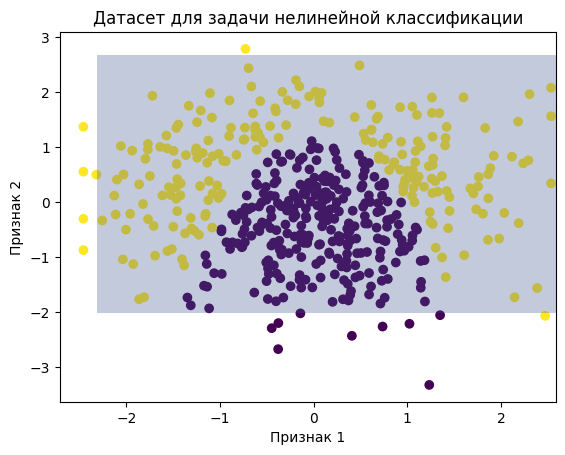

In [48]:
x1_min, x1_max = x_test[:, 0].min()-0.2, x_test[:, 0].max()+0.2
x2_min, x2_max = x_test[:, 1].min()-0.2, x_test[:, 1].max()+0.2
x1_points, x2_points = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

svm_anses = svm.predict(np.array([x1_points.ravel(), x2_points.ravel()]).T)
#svm_anses = get_class(svm_anses)
svm_anses = svm_anses.reshape(x1_points.shape)

plt.scatter(x_transformed[:,0], x_transformed[:,1], c=y)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Датасет для задачи нелинейной классификации')
plt.contourf(x1_points, x2_points, svm_anses, alpha=0.3)
plt.show()

In [49]:
svm.w

array([-0.00707233, -0.00707233, -0.00707233, -0.00707233, -0.00707233])